In [1]:
import numpy as np
import re
import torch
import os
import torch.nn as nn
from torch.utils.data  import Dataset,DataLoader
import json
import cv2
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence

In [2]:
# from roboflow import Roboflow
# rf = Roboflow(api_key="z58G9rKRQOwBpbkuwYoJ")
# project = rf.workspace("pallet-9crub").project("pallet-parts-segmentation")
# version = project.version(2)
# dataset = version.download("coco-segmentation")

In [3]:
bos_token = "<s>"
eos_token = "</s>"
pad_token = "<pad>"
task_token = "<QUADBOX>"

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

In [4]:
#Lets encode the tokens
encoded_tokens = {}
for ind, token in enumerate([bos_token,eos_token,pad_token,task_token]):
    if token not in encoded_tokens:
        encoded_tokens[token] = encoded_tokens.get(token,ind)

loc_tokens = {}
for i in range(0,1000):
    loc_tokens[f"<loc_{i}>"] = loc_tokens.get(f"<loc_{i}>",i + 1 + max(encoded_tokens.values()))

classes = ["pallets", "pallet_side", "pallet_top"]
class_tokens = {}

for ind, cls in enumerate(classes):
    class_tokens[cls] = class_tokens.get(cls, ind + 1 + max(loc_tokens.values()))


all_tokens = encoded_tokens | loc_tokens | class_tokens


In [5]:
id_to_token = {v:k for k,v in all_tokens.items()}

In [6]:
def normalize_for_florence(targets,img_w,img_h):
    #tek x, çift y
    #targets np array -> [[x,y],[x,y],[x,y],[x,y]]
    xs = targets[:,0]
    ys = targets[:,1]
    xs_normalized = np.clip((xs / img_w) * 1000, 0, 999)
    ys_normalized = np.clip((ys / img_h) * 1000, 0, 999)
    targets[:,0] = xs_normalized
    targets[:,1] = ys_normalized

    return targets

In [7]:
normalize_for_florence(np.array([[0,100],[100,30],[100,600],[0,600]]),2357,968)

array([[  0, 103],
       [ 42,  30],
       [ 42, 619],
       [  0, 619]])

In [8]:
class FlorenceDataset(Dataset):
    def __init__(self, annotation_file, img_dir, all_tokens=None, max_seq_len=512):
        self.img_dir = img_dir
        self.all_tokens = all_tokens  # token -> id mapping (opsiyonel)
        self.max_seq_len = max_seq_len

        with open(annotation_file, "r", encoding="utf-8") as f:
            coco_data = json.load(f)

        # Görsel metaverileri: {image_id: {"file_name": ..., "width": ..., "height": ...}}
        self.images = {img["id"]: img for img in coco_data["images"]}

        # Kategori isimleri: {category_id: name}
        self.categories = {cat["id"]: cat["name"] for cat in coco_data.get("categories", [])}
        print(self.categories)
        # Görsel ID'lerine göre anotasyonları grupla
        self.annotations = {}
        for ann in coco_data["annotations"]:
            # RLE veya boş segmentasyonları atla (sadece poligon listeleri)
            if ann.get("iscrowd", 0) == 1 or not isinstance(ann.get("segmentation"), list):
                continue

            img_id = ann["image_id"]
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(ann)

        # Sadece en az 1 geçerli anotasyonu olan görsel ID'lerini listele
        self.img_ids = [img_id for img_id in self.images.keys() if img_id in self.annotations]

    def __len__(self):
        return len(self.img_ids)


    def order_quad(self, pts):
      """(4,2) piksel koordinatı -> sol-üst köşeden başlayıp saat yönünde sıralı."""
      pts = np.asarray(pts, dtype=np.float32)
      c = pts.mean(axis=0)
      ang = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
      pts = pts[np.argsort(ang)]                    # y aşağı olduğu için artan açı = ekranda saat yönü
      start = np.argmin(pts[:, 0] + pts[:, 1])      # sol-üste en yakın köşe
      return np.roll(pts, -start, axis=0)

    def normalize_for_florence(self,targets,img_w,img_h):
        #tek x, çift y
        #targets np array -> [[x,y],[x,y],[x,y],[x,y]]
        xs = targets[:,0]
        ys = targets[:,1]
        xs_normalized = np.clip((xs / img_w) * 1000, 0, 999).astype(int)
        ys_normalized = np.clip((ys / img_h) * 1000, 0, 999).astype(int)
        targets[:,0] = xs_normalized
        targets[:,1] = ys_normalized

        return targets

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_meta = self.images[img_id]
        img_w = img_meta["width"]
        img_h = img_meta["height"]

        img_path = os.path.join(self.img_dir, img_meta["file_name"])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (640,640))

        anns = self.annotations[img_id]

        target_coords = []      # Sadece int koordinatlar: [[x1, y1, ...], [x1, y1, ...]]
        target_token_strs = []  # Token metinleri: ['<loc_X>', '<loc_Y>', ...]
        target_token_ids = []   # Sayısal ID'ler (all_tokens verilmişse)

        for ann in anns:
            cat_name = self.categories.get(ann["category_id"], "object")

            # Bir anotasyon birden fazla poligon parçası içerebilir
            for poly in ann["segmentation"]:

                targets = np.array(poly, dtype=np.float32).reshape(-1, 2)[:-1]   # kapanış noktasını at
                #assert targets.shape == (4, 2), f"4 köşe bekleniyordu: {targets.shape}"

                targets = self.order_quad(targets).astype(int)
                # 1. Ham koordinatları 0-999 aralığında normalize et
                norm_coords = self.normalize_for_florence(targets, img_w, img_h)
                target_coords.append(norm_coords)

                # 2. Koordinatları Florence token string'lerine dönüştür
                loc_tokens = [cat_name] + [f"<loc_{coord}>"  for val in norm_coords for coord in val]


                # 3. İsteğe bağlı: Sayısal ID'leri çek
                if self.all_tokens:
                    target_token_ids.extend([self.all_tokens[t] for t in loc_tokens if t in self.all_tokens])

        return {
            "image": image,
            "img_id": img_id,
            "orig_size": (img_h, img_w),
            "coordinates": target_coords,         # Ham int koordinat listeleri
            "token_strings": target_token_strs,   # ['<loc_12>', '<loc_450>', ...]
            "token_ids": target_token_ids         # [ID1, ID2, ...]
        }

In [9]:
def florence_collate_fn(batch):
    #Resim  hcw ve normalize et
    images = []
    for item in batch:
        image = item["image"]
        image = torch.from_numpy(image).permute(2,0,1).float() / 255.
        image = (image - IMAGENET_MEAN) / IMAGENET_STD
        images.append(image)
    pixel_values = torch.stack(images)

    decoder_input_ids = []
    targets = []
    for item in batch:
        token_ids = item["token_ids"]
        bos_id = all_tokens[bos_token]
        eos_id = all_tokens[eos_token]
        pad_id = all_tokens[pad_token]
        task_token_id = all_tokens[task_token]
        seq = [task_token_id] + [bos_id] + token_ids
        seq_targets = [bos_id] + token_ids + [eos_id]
        decoder_input_ids.append(torch.tensor(seq, dtype=torch.long))
        targets.append(torch.tensor(seq_targets, dtype=torch.long))
    targets = pad_sequence(targets, batch_first=True, padding_value=pad_id)
    decoder_input_ids = pad_sequence(decoder_input_ids, batch_first=True, padding_value=pad_id)
    #decoder_attention_mask = (targets != pad_id).long()



    return {
        "pixel_values": pixel_values,
        "labels": targets,
        "decoder_input_ids": decoder_input_ids,
        #"decoder_attention_mask" : decoder_attention_mask
        }

In [10]:
# data_dir = "/home/rivian/Desktop/Datasets/pallet-parts-segmentation.v2i.coco-segmentation/train"
# annotation_file = "/home/rivian/Desktop/Datasets/pallet-parts-segmentation.v2i.coco-segmentation/train/_annotations.coco.json"

# dataset = FlorenceDataset(annotation_file,data_dir,all_tokens)

root = "./pallet-parts-segmentation-2"

train_ds = FlorenceDataset(f"{root}/train/_annotations.coco.json", f"{root}/train", all_tokens)
val_ds   = FlorenceDataset(f"{root}/valid/_annotations.coco.json", f"{root}/valid", all_tokens)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=8,
                          pin_memory=True, collate_fn=florence_collate_fn, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=8,
                          pin_memory=True, collate_fn=florence_collate_fn)

{0: 'pallets', 1: 'pallet_side', 2: 'pallet_top'}
{0: 'pallets', 1: 'pallet_side', 2: 'pallet_top'}


In [11]:
b = next(iter(train_loader))
print(b["pixel_values"].shape, b["decoder_input_ids"].shape, b["labels"].shape)
print(b["decoder_input_ids"][0][:12])
print(b["labels"][0][:12])   # input'tan bir kayık olmalı

torch.Size([4, 3, 640, 640]) torch.Size([4, 29]) torch.Size([4, 29])
tensor([   3,    0, 1006,   44,  491,  532,  260,  972,  394,  511,  777, 1005])
tensor([   0, 1006,   44,  491,  532,  260,  972,  394,  511,  777, 1005,  514])


In [12]:
from florence_quadbox import QuadModel, train, generate

In [13]:
model = QuadModel(vocab_size=len(all_tokens), pad_id=all_tokens[pad_token]).cuda()


Backbone davit_base_fl.msft_florence2: 1024 kanal | pretrain mean/std (0.485, 0.456, 0.406)/(0.229, 0.224, 0.225) (script ImageNet mean/std kullanıyor; farklıysa IMAGENET_MEAN/STD'yi güncelle)


In [ ]:
train(model, train_loader, val_loader, pad_id=all_tokens[pad_token], epochs= 20)

130.3M parametre | amp torch.bfloat16 | 13440 adım


Epoch 1/20:   0%|          | 0/672 [00:00<?, ?it/s]

val:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1/20 | train 5.8412 | val_ce 6.2930 | loc_mae 320.9 bin  ✓


Epoch 2/20:   0%|          | 0/672 [00:00<?, ?it/s]

val:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 2/20 | train 5.4880 | val_ce 5.2804 | loc_mae 247.4 bin  ✓


Epoch 3/20:   0%|          | 0/672 [00:00<?, ?it/s]

In [ ]:
loc0 = all_tokens["<loc_0>"]
cls_ids = set(class_tokens.values())
task_id = all_tokens[task_token]
bos_id = all_tokens[bos_token]
eos_id = all_tokens[eos_token]

@torch.no_grad()
def predict(model, img_path, device="cuda", max_len=200):
    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    x = cv2.resize(image, (640, 640))
    x = (torch.from_numpy(x).permute(2, 0, 1).float() / 255. - IMAGENET_MEAN) / IMAGENET_STD

    seq = generate(model, x[None].to(device), task_id, bos_id, eos_id, max_len)[0].tolist()
    if eos_id in seq:
        seq = seq[:seq.index(eos_id)]

    preds = []
    for i in range(0, len(seq) - 8, 9):          # 9'luk bloklar: sınıf + 8 loc
        cls, locs = seq[i], seq[i + 1:i + 9]
        if cls not in cls_ids or not all(loc0 <= v < loc0 + 1000 for v in locs):
            continue                              # bozuk blok, atla
        pts = (np.array(locs).reshape(4, 2) - loc0 + 0.5) / 1000 * [w, h]
        preds.append((id_to_token[cls], pts))
    return image, preds


def show(image, preds):
    out = image.copy()
    for name, pts in preds:
        p = pts.astype(np.int32).reshape(-1, 1, 2)
        cv2.polylines(out, [p], True, (0, 255, 0), 3)
        cv2.putText(out, name, tuple(int(v) for v in p[0, 0]),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    plt.figure(figsize=(10, 10))
    plt.imshow(out)
    plt.axis("off")
    plt.show()

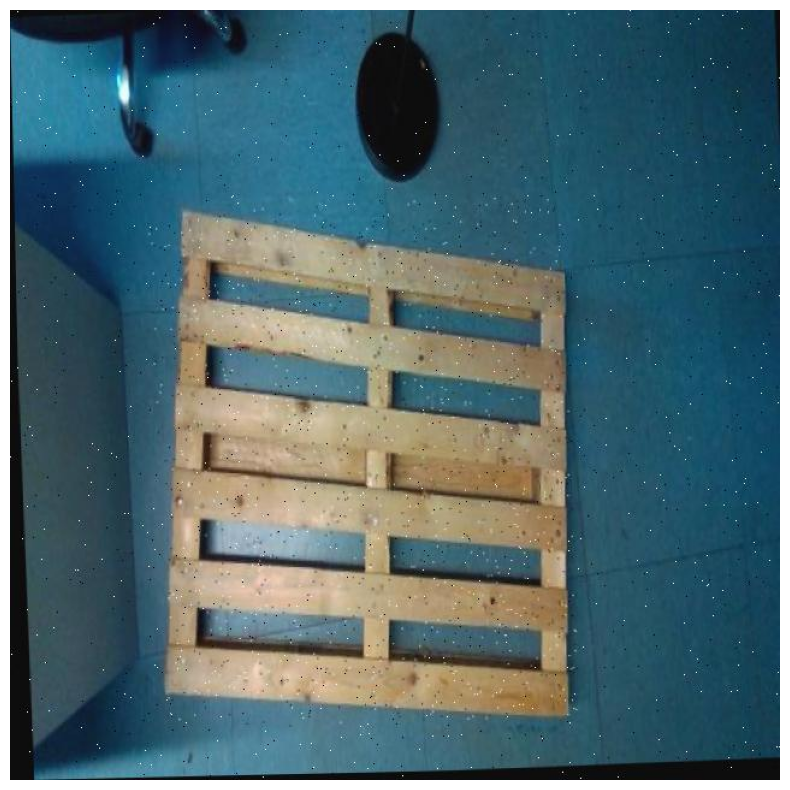

In [ ]:
image, preds = predict(model, "/home/uygarusta/Oriented-Centernet/florence_implementasyon/pallet-parts-segmentation-2/train/1_png_jpg.rf.8d8a46b1ff3ac4c03d2789d29bf31aa1.jpg")
show(image, preds)

In [ ]:
preds

[]